In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import fnmatch
import json
import os

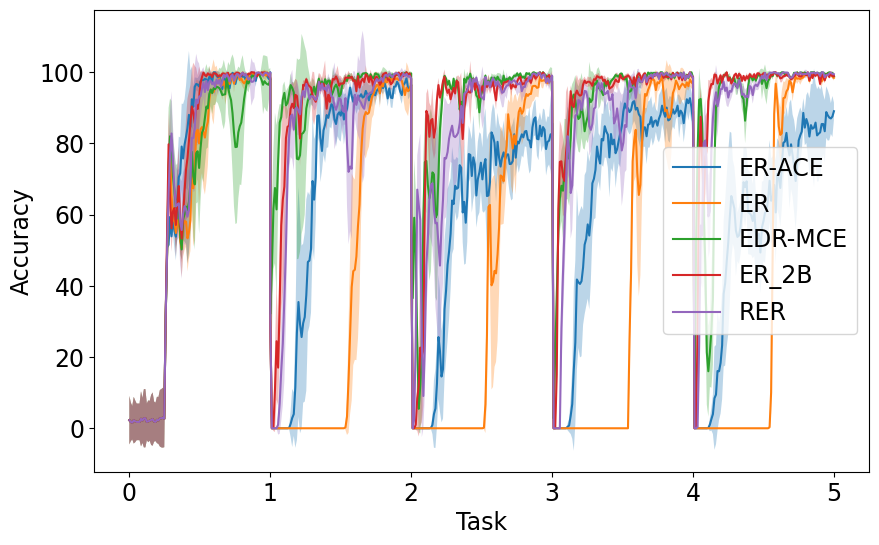

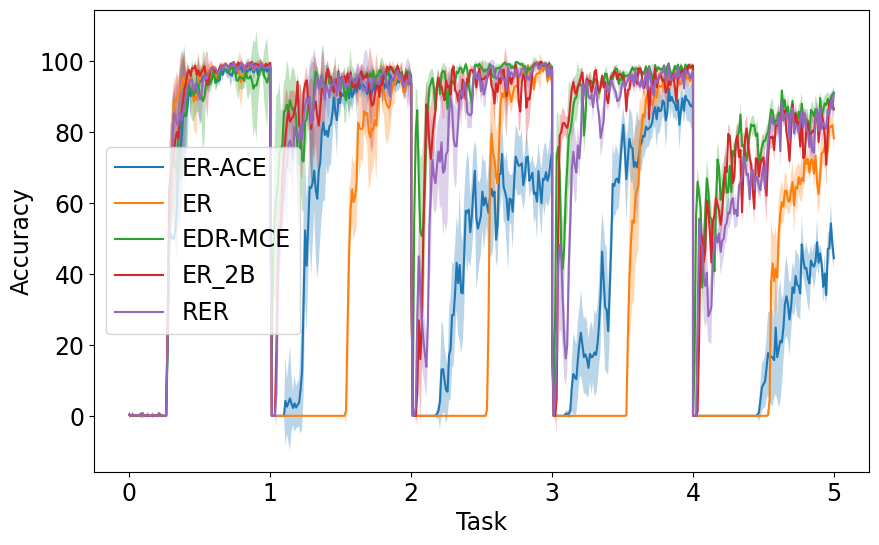

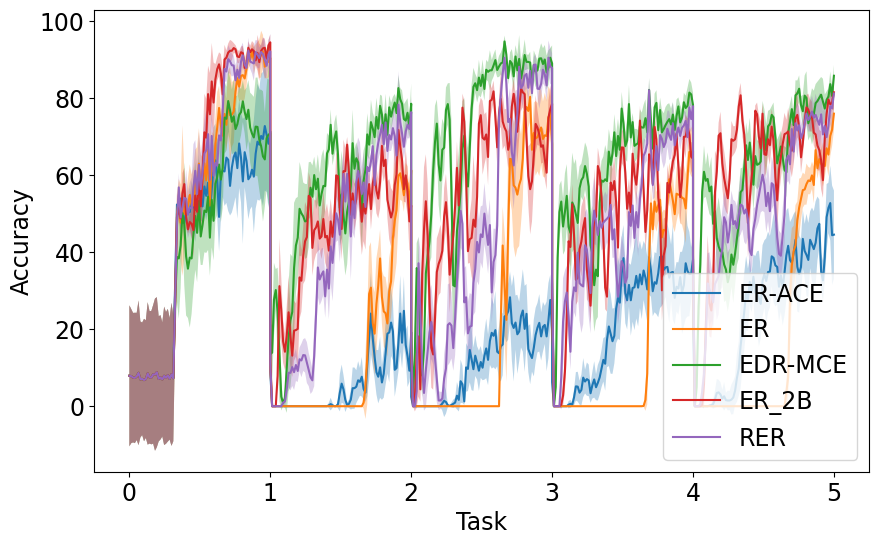

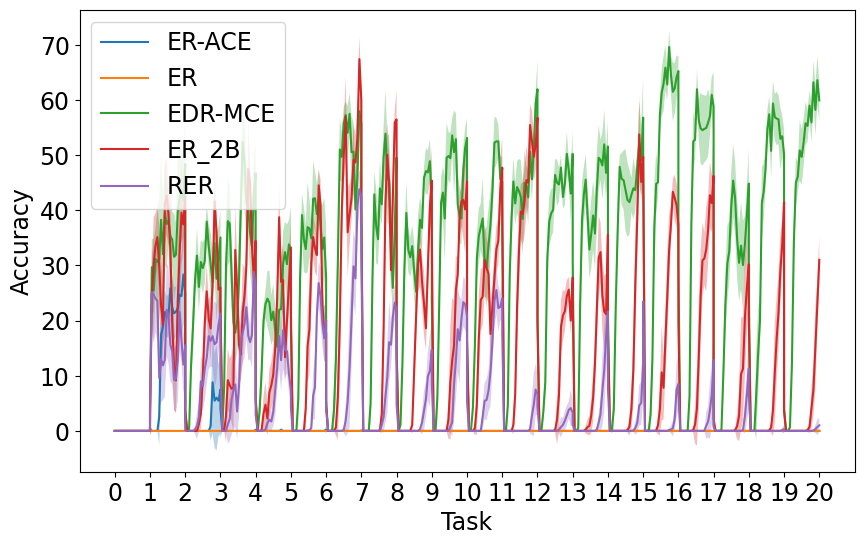

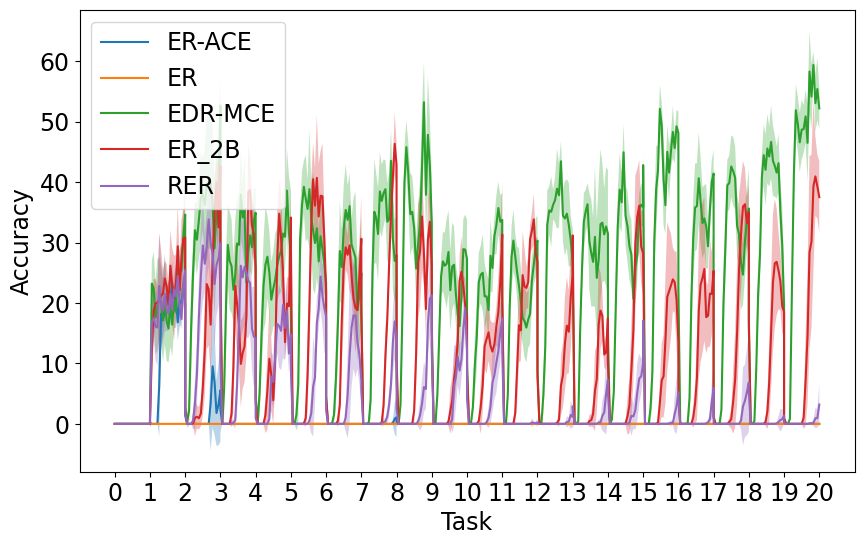

In [2]:
# plt.rcParams["font.family"] = "sans-serif"
# plt.rcParams["font.sans-serif"] = ["Noto Sans"]
plt.rcParams["font.size"] = 17
figsize = (10, 6)
path_save_plots = "plots_er_resnet18_all_metrics"

#no_delayed_batches = [0.1, 0.2, 0.3, 0.4]
#delay_labels = [10, 50, 80, 100]

no_delayed_batches = [0.4]
delay_labels = [100]
num_task = 5

datasets = ["SplitMNIST", "SplitFashionMNIST", "SplitCIFAR10", "SplitCIFAR100", "SplitMiniImagenet"]
# datasets = ["SplitCIFAR10"]
# strategies = [["EDR", "RER", "ER_l", "ER_2B"], ["EDR", "ER_f"]]
# strategies = [["ER_2B", "ER_l", "EDR", "ER-ACE"], ["ER_2B", "ER_l", "EDR", "ER-ACE-Agu"]]
strategies = [["ER-ACE", "ER_l", "EDR-ACE", "ER_2B", "RER"]]


for dataset in datasets:
    for no_delayed_batch in no_delayed_batches:
        for delay_label in delay_labels:
            for value_strategies in strategies:
                
                _, ax = plt.subplots(figsize=figsize)
                for strategy in value_strategies:
                    if dataset == "SplitCIFAR100" or dataset == "SplitMiniImagenet":
                        num_task = 20

                    # List all files in the folder (adjust pattern if needed)
                    results_folder = f"results_{dataset}"
                    files = [f for f in os.listdir(results_folder) if fnmatch.fnmatch(f, f"results_{dataset}_{delay_label}_{no_delayed_batch}_32_{num_task}_{strategy}_64_128_5_1_*.json")]

                    accuracies = []
                    # list_ttt_windowed_task_index = []
                    for fname in files:
                        with open(os.path.join(results_folder, fname), "r") as f:
                            data = json.load(f)
                            
                            acc = np.array(data["ttt_metrics_per_window_accuracy"])
                            ttt_windowed_task_index = np.array(data["ttt_windowed_task_index"])
                            # list_ttt_windowed_task_index.append(ttt_windowed_task_index)
                            accuracies.append(acc)

                    # Stack all runs into a single array: shape (n_runs, n_steps)
                    runs_accuracy = np.stack(accuracies)
                    # runs_task_index = np.stack(list_ttt_windowed_task_index)

                    mean_accuracy = runs_accuracy.mean(axis=0)
                    std_accuracy = runs_accuracy.std(axis=0)

                    # mean_task_index = runs_task_index.mean(axis=0)
                    mean_task_index = ttt_windowed_task_index
                    if strategy == "ER_l":
                        strategy = "ER"
                    if strategy == "EDR-ACE":
                        strategy = "EDR-MCE"

                    ax.plot(mean_task_index, mean_accuracy, label=strategy)
                    ax.fill_between(mean_task_index, mean_accuracy - std_accuracy, mean_accuracy + std_accuracy, alpha=0.3)  
                    ax.set_xlabel("Task")
                    ax.set_ylabel("Accuracy")
                    plt.xticks(range(0, int(max(mean_task_index))+1))
                    ax.legend()

                plt.savefig(f"{path_save_plots}/results_{dataset}_{delay_label}_{no_delayed_batch}_32_5_{'_'.join(value_strategies)}_64_128_5_1_all.png", bbox_inches='tight', dpi=300)



In [17]:
#Table for final results


plt.rcParams["font.size"] = 17
figsize = (10, 6)

num_task = 5
no_delayed_batches = [0.4]
delay_labels = [100]
# datasets = ["SplitMNIST", "SplitFashionMNIST", "SplitCIFAR10", "SplitCIFAR100", "SplitMiniImagenet"]
datasets = ["SplitMiniImagenet"]
strategies = ["ER-ACE", "EDR", "RER", "ER_l", "ER_2B", "EDR-ACE"]

for dataset in datasets:
    for no_delayed_batch in no_delayed_batches:
        for delay_label in delay_labels:
            for strategy in strategies:
                if dataset == "SplitCIFAR100" or dataset == "SplitMiniImagenet":
                    num_task = 20
                
                # List all files in the folder (adjust pattern if needed)
                results_folder = f"results_{dataset}"
                files = [f for f in os.listdir(results_folder) if fnmatch.fnmatch(f, f"results_{dataset}_{delay_label}_{no_delayed_batch}_32_{num_task}_{strategy}_64_128_5_1_*.json")]

                list_ttt_cumulative_accuracy = []
                list_accuracy_seen_avg = []
                list_anytime_accuracy_all_avg = []
                list_accuracy_all_avg = []

                list_accuracy_final = []
                list_forgetting = []
                list_backward_transfer = []
                list_forward_transfer = []
                list_total_flops = []
                for fname in files:
                    with open(os.path.join(results_folder, fname), "r") as f:
                        data = json.load(f)
                        
                        
                        ttt_cumulative_accuracy = np.array(data["ttt_cumulative_accuracy"])
                        accuracy_seen_avg = np.array(data["accuracy_seen_avg"])
                        anytime_accuracy_all_avg = np.array(data["anytime_accuracy_all_avg"])
                        accuracy_all = np.array(data["accuracy_all"])
                        accuracy_all_avg = accuracy_all.mean(axis=0)

                        list_ttt_cumulative_accuracy.append(ttt_cumulative_accuracy)
                        list_accuracy_seen_avg.append(accuracy_seen_avg)
                        list_anytime_accuracy_all_avg.append(anytime_accuracy_all_avg)
                        list_accuracy_all_avg.append(accuracy_all_avg)

                        list_accuracy_final.append(data["accuracy_final"])
                        list_forgetting.append(data["forgetting"])
                        list_backward_transfer.append(data["backward_transfer"])
                        list_forward_transfer.append(data["forward_transfer"])
                        list_total_flops.append(data["total_flops"])

                # Stack all runs into a single array: shape (n_runs, n_steps)
                runs_ttt_cumulative_accuracy = np.stack(list_ttt_cumulative_accuracy)
                runs_accuracy_seen_avg = np.stack(list_accuracy_seen_avg)
                runs_anytime_accuracy_all_avg = np.stack(list_anytime_accuracy_all_avg)
                runs_accuracy_all_avg = np.stack(list_accuracy_all_avg)

                runs_accuracy_final = np.stack(list_accuracy_final)
                runs_forgetting = np.stack(list_forgetting)
                runs_backward_transfer = np.stack(list_backward_transfer)
                runs_forward_transfer = np.stack(list_forward_transfer)
                runs_total_flops = np.stack(list_total_flops)

                mean_ttt_cumulative_accuracy = runs_ttt_cumulative_accuracy.mean(axis=0)
                std_ttt_cumulative_accuracy = runs_ttt_cumulative_accuracy.std(axis=0)

                mean_accuracy_seen_avg = runs_accuracy_seen_avg.mean(axis=0)
                std_accuracy_seen_avg = runs_accuracy_seen_avg.std(axis=0)

                mean_anytime_accuracy_all_avg = runs_anytime_accuracy_all_avg.mean(axis=0)
                std_anytime_accuracy_all_avg = runs_anytime_accuracy_all_avg.std(axis=0)

                mean_accuracy_all_avg = runs_accuracy_all_avg.mean(axis=0)
                std_accuracy_all_avg = runs_accuracy_all_avg.std(axis=0)

                mean_accuracy_final = runs_accuracy_final.mean()
                std_accuracy_final = runs_accuracy_final.std()

                mean_forgetting = runs_forgetting.mean()
                std_forgetting = runs_forgetting.std()

                mean_backward_transfer = runs_backward_transfer.mean()
                std_backward_transfer = runs_backward_transfer.std()

                mean_forward_transfer = runs_forward_transfer.mean()
                std_forward_transfer = runs_forward_transfer.std()

                mean_total_flops = runs_total_flops.mean()
                std_total_flops = runs_total_flops.std()

                print(f"Dataset: {dataset}, Strategy: {strategy}")
                # print(f"Final TTT Cumulative Accuracy: {mean_ttt_cumulative_accuracy} ± {std_ttt_cumulative_accuracy}")
                # print(f"Final Accuracy Seen Avg: {mean_accuracy_seen_avg} ± {std_accuracy_seen_avg}")
                # print(f"Final Anytime Accuracy All Avg: {mean_anytime_accuracy_all_avg} ± {std_anytime_accuracy_all_avg}")
                # print(f"Final Accuracy All Avg: {mean_accuracy_all_avg} ± {std_accuracy_all_avg}")
                
                print(f"Final Accuracy: {mean_accuracy_final} ± {std_accuracy_final}")
                print(f"Final Forgetting: {mean_forgetting} ± {std_forgetting}")
                print(f"Final Backward Transfer: {mean_backward_transfer} ± {std_backward_transfer}")
                print(f"Final Forward Transfer: {mean_forward_transfer} ± {std_forward_transfer}")
                print(f"Total TFLOPs: {mean_total_flops / 1e12:.2f} ± {std_total_flops / 1e12:.2f}")

Dataset: SplitMiniImagenet, Strategy: ER-ACE
Final Accuracy: 0.016789999976754188 ± 0.006907308236969607
Final Forgetting: 0.04781052656471729 ± 0.01336997920017902
Final Backward Transfer: 0.003156842425232753 ± 0.010218960761161838
Final Forward Transfer: 0.00105263163568452 ± 4.707518605561757e-06
Total TFLOPs: 600.49 ± 0.00
Dataset: SplitMiniImagenet, Strategy: EDR
Final Accuracy: 0.02043000012636185 ± 0.003237606766740976
Final Forgetting: 0.15284210741519927 ± 0.0095849610454261
Final Backward Transfer: -0.1866484224796295 ± 0.014497425182578252
Final Forward Transfer: 0.00105263163568452 ± 4.707518605561757e-06
Total TFLOPs: 394.47 ± 0.00
Dataset: SplitMiniImagenet, Strategy: RER
Final Accuracy: 0.03835000023245812 ± 0.0049128897698312935
Final Forgetting: 0.20941052585840225 ± 0.011248507574304371
Final Backward Transfer: -0.06301052570343017 ± 0.0070674635196382885
Final Forward Transfer: 0.00105263163568452 ± 4.707518605561757e-06
Total TFLOPs: 404.35 ± 0.00
Dataset: SplitMin